In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

random_state = 42

# Load Ames dataset
data_path = '/mnt/c/Users/futha/source/python-projects/pyml-book/datasets/AmesHousing.txt'
df = pd.read_csv(data_path, sep='\t',)

# Initial Inspection

In [2]:
# Shape of the dataset
df.shape

(2930, 82)

In [3]:
# View the first 10 examples
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [4]:
# View the last 10 examples
df.tail(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2920,2921,923228310,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,71000
2921,2922,923229110,90,RL,55.0,12640,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,150900
2922,2923,923230040,90,RL,63.0,9297,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,7,2006,WD,Family,188000
2923,2924,923250060,20,RL,80.0,17400,Pave,NaN,Reg,Low,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,160000
2924,2925,923251180,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,131000
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000
2929,2930,924151050,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,188000


In [5]:
# View 10 examples randomly sampled from the dataset
df.sample(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2482,2483,531452210,60,RL,NaN,9019,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,150000
2198,2199,909251030,30,RL,54.0,7223,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,4,2007,WD,Normal,136500
169,170,902102100,50,RM,60.0,4800,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,1,2010,COD,Abnorml,80400
1242,1243,535179060,20,RL,80.0,11900,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,166000
1295,1296,902128075,30,RM,60.0,5400,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,120000
2827,2828,908186090,180,RM,35.0,3675,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,142500
2751,2752,906380150,20,RL,64.0,7488,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,183600
1085,1086,528235020,60,RL,80.0,9024,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,179000
2030,2031,903450060,50,RM,NaN,7758,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,169500
1539,1540,909425085,50,RL,70.0,12392,Pave,NaN,Reg,Bnk,...,0,NaN,NaN,NaN,0,4,2008,WD,Normal,263400


In [6]:
pd.set_option('display.max_rows', None) # Remove visualization limits
df.dtypes # Check data types of the dataset

Order                int64
PID                  int64
MS SubClass          int64
MS Zoning              str
Lot Frontage       float64
Lot Area             int64
Street                 str
Alley                  str
Lot Shape              str
Land Contour           str
Utilities              str
Lot Config             str
Land Slope             str
Neighborhood           str
Condition 1            str
Condition 2            str
Bldg Type              str
House Style            str
Overall Qual         int64
Overall Cond         int64
Year Built           int64
Year Remod/Add       int64
Roof Style             str
Roof Matl              str
Exterior 1st           str
Exterior 2nd           str
Mas Vnr Type           str
Mas Vnr Area       float64
Exter Qual             str
Exter Cond             str
Foundation             str
Bsmt Qual              str
Bsmt Cond              str
Bsmt Exposure          str
BsmtFin Type 1         str
BsmtFin SF 1       float64
BsmtFin Type 2         str
B

In [7]:
# Print a concise summary of the dataset
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

# Data Quality Checks

In [8]:
# Number of unique values
df.nunique()

Order              2930
PID                2930
MS SubClass          16
MS Zoning             7
Lot Frontage        128
Lot Area           1960
Street                2
Alley                 2
Lot Shape             4
Land Contour          4
Utilities             3
Lot Config            5
Land Slope            3
Neighborhood         28
Condition 1           9
Condition 2           8
Bldg Type             5
House Style           8
Overall Qual         10
Overall Cond          9
Year Built          118
Year Remod/Add       61
Roof Style            6
Roof Matl             8
Exterior 1st         16
Exterior 2nd         17
Mas Vnr Type          4
Mas Vnr Area        445
Exter Qual            4
Exter Cond            5
Foundation            6
Bsmt Qual             5
Bsmt Cond             5
Bsmt Exposure         4
BsmtFin Type 1        6
BsmtFin SF 1        995
BsmtFin Type 2        6
BsmtFin SF 2        274
Bsmt Unf SF        1137
Total Bsmt SF      1058
Heating               6
Heating QC      

In [9]:
# Percentage of null values
null_threshold = 0.15
cond_high_null_val_cols = df.isnull().mean() > null_threshold
print(f'Features with a percentage of null values > {null_threshold}: {df.columns[cond_high_null_val_cols].tolist()}')

Features with a percentage of null values > 0.15: ['Lot Frontage', 'Alley', 'Mas Vnr Type', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature']


In [10]:
# Duplicates
n_duplicates = df.duplicated().sum()
print(f'Number of duplicates: {n_duplicates}')

Number of duplicates: 0


Some features have spaces in their name. There are also some typos.

In [11]:
# Rename features according to metadata
name_map = {
    'MS SubClass':  'MSSubClass',
    'MS Zoning': 'MSZoning',
    'Lot Shape' : 'LotShape',
    'Land Contour' : 'LandContour',
    'Lot Config' : 'LotConfig',
    'Lot Frontage': 'LotFrontage',
    'Lot Area': 'LotArea',
    'Land Slope' : 'LandSlope',
    'Condition 1' : 'Condition1',
    'Condition 2' : 'Condition2',
    'BsmtFin SF 1': 'BsmtFinSF1',
    'BsmtFin SF 2': 'BsmtFinSF2',
    'Bsmt Unf SF': 'BsmtUnfSF',
    'Total Bsmt SF': 'TotalBsmtSF',
    '1st Flr SF': '1stFlrSF',
    '2nd Flr SF': '2ndFlrSF',
    'Low Qual Fin SF': 'LowQualFinSF',
    'Gr Liv Area': 'GrLivArea',
    'Bsmt Full Bath': 'BsmtFullBath',
    'Bsmt Half Bath': 'BsmtHalfBath', 
    'Full Bath': 'FullBath', 
    'Half Bath': 'HalfBath',
    'Bedroom AbvGr': 'BedroomAbvGr',
    'Kitchen AbvGr': 'KitchenAbvGr',
    'Bldg Type' : 'BldgType',
    'House Style' : 'HouseStyle',
    'Overall Qual' : 'OverallQual',
    'Overall Cond' : 'OverallCond',
    'Roof Style' : 'RoofStyle',
    'Roof Matl' : 'RoofMatl',
    'Exterior 1st' : 'Exterior1st',
    'Exterior 2nd' : 'Exterior2nd',
    'Mas Vnr Type' : 'MasVnrType',
    'Mas Vnr Area' : 'MasVnrArea',
    'Exter Qual' : 'ExterQual',
    'Exter Cond' : 'ExterCond',
    'Bsmt Qual' : 'BsmtQual',
    'Bsmt Cond' : 'BsmtCond',
    'Bsmt Exposure' : 'BsmtExposure',
    'BsmtFin Type 1' : 'BsmtFinType1',
    'BsmtFin Type 2' : 'BsmtFinType2',
    'Heating QC' : 'HeatingQC',
    'Central Air' : 'CentralAir',
    'Kitchen Qual' : 'KitchenQual',
    'Fireplace Qu' : 'FireplaceQu',
    'Garage Type' : 'GarageType',
    'Garage Finish' : 'GarageFinish',
    'Garage Qual' : 'GarageQual',
    'Garage Cond' : 'GarageCond',
    'Garage Yr Blt': 'GarageYrBlt',
    'Garage Cars': 'GarageCars',
    'Garage Area': 'GarageArea',
    'Paved Drive' : 'PavedDrive',
    'Pool QC' : 'PoolQC',
    'Misc Feature' : 'MiscFeature',
    'Sale Type' : 'SaleType',
    'Sale Condition': 'SaleCondition',
    'TotRms AbvGrd': 'TotRmsAbvGrd',
    'Wood Deck SF': 'WoodDeckSF',
    'Open Porch SF': 'OpenPorchSF',
    'Enclosed Porch': 'EnclosedPorch',
    '3Ssn Porch': '3SsnPorch',
    'Screen Porch': 'ScreenPorch',
    'Pool Area': 'PoolArea',
    'Year Built': 'YearBuilt',
    'Year Remod/Add': 'YearRemod/Add',
    'Misc Val': 'MiscVal',
    'Mo Sold': 'MoSold',
    'Yr Sold': 'YrSold'
}

df.rename(name_map, axis=1, inplace=True)

For each feature, both categorical or numerical, check if the values of the examples in the dataset actually
respect the valid categories or numerical bounds.

In [12]:
# Valid categorical entries according to the ranges and categories indicated in the dataset metadata and domain knowledge
categorical_invariants = {
    'MSSubClass': [20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 150, 160, 180, 190],
    'MSZoning': ['A', 'C', 'FV', 'I', 'RH', 'RL', 'RP', 'RM'],
    'Street': ['Grvl', 'Pave'],
    'Alley': ['Grvl', 'Pave', 'NA'],
    'LotShape': ['Reg', 'IR1', 'IR2', 'IR3'],
    'LandContour': ['Lvl', 'Bnk', 'HLS', 'Low'],
    'Utilities': ['AllPub', 'NoSewr', 'NoSeWa', 'ELO'],
    'LotConfig': ['Inside', 'Corner', 'CulDSac', 'FR2', 'FR3'],
    'LandSlope': ['Gtl', 'Mod', 'Sev'],
    'Neighborhood': ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide',
                      'ClearCr', 'CollgCr', 'Crawfor', 'Edwards',
                      'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel',
                      'NAmes', 'NoRidge', 'NPkVill', 'NridgHt',
                      'NWAmes', 'OldTown', 'SWISU', 'Sawyer',
                      'SawyerW', 'Somerst', 'StoneBr', 'Timber',
                      'Veenker', 'Greens', 'GrnHill', 'Landmrk'],
    'Condition1': ['Artery', 'Feedr', 'Norm', 'RRNn', 'RRAn',
                   'PosN', 'PosA', 'RRNe', 'RRAe'],
    'Condition2': ['Artery', 'Feedr', 'Norm', 'RRNn', 'RRAn',
                   'PosN', 'PosA', 'RRNe', 'RRAe'],
    'BldgType': ['1Fam', '2FmCon', 'Duplx', 'TwnhsE', 'TwnhsI'],
    'HouseStyle': ['1Story', '1.5Fin', '1.5Unf', '2Story',
                   '2.5Fin', '2.5Unf', 'SFoyer', 'SLvl'],
    'OverallQual': [i for i in range(10, 0, -1)],
    'OverallCond': [i for i in range(10, 0, -1)],
    'RoofStyle': ['Flat', 'Gable', 'Gambrel', 'Hip',
                  'Mansard', 'Shed'],
    'RoofMatl': ['ClyTile', 'CompShg', 'Membran', 'Metal',
                 'Roll', 'Tar&Grv', 'WdShake', 'WdShngl'],
    'Exterior1st': ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace',
                    'CBlock', 'CemntBd', 'HdBoard', 'ImStucc',
                    'MetalSd', 'Other', 'Plywood', 'PreCast', 
                    'Stone', 'Stucco', 'VinylSd', 'WdSdng', 
                    'WdShng'],
    'Exterior2nd': ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace',
                    'CBlock', 'CemntBd', 'HdBoard', 'ImStucc',
                    'MetalSd', 'Other', 'Plywood', 'PreCast', 
                    'Stone', 'Stucco', 'VinylSd', 'WdSdng', 
                    'WdShng'],
    'MasVnrType': ['BrkCmn', 'BrkFace', 'CBlock', 'None',
                   'Stone'],
    'ExterQual': ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
    'ExterCond': ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
    'Foundation': ['BrkTil', 'CBlock', 'PConc', 'Slab',
                   'Stone', 'Wood'],
    'BsmtQual': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],
    'BsmtCond': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],
    'BsmtExposure': ['Gd', 'Av', 'Mn', 'No', 'NA'],
    'BsmtFinType1': ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NA'],
    'BsmtFinType2': ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NA'],
    'Heating': ['Floor', 'GasA', 'GasW', 'Grav', 'OthW', 'Wall'],
    'HeatingQC': ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
    'CentralAir': ['N', 'Y'],
    'Electrical': ['SBrkr', 'FuseA', 'FuseF', 'FuseP', 'Mix'],
    'KitchenQual': ['Ex', 'Gd', 'TA', 'Fa', 'Po'],
    'Functional': ['Typ', 'Min1', 'Min2', 'Mod', 'Maj1',
                   'Maj2', 'Sev', 'Sal'],
    'FireplaceQu': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],
    'GarageType': ['2Types', 'Attchd', 'Basment', 'BuiltIn',
                   'CarPort', 'Detchd', 'NA'],
    'GarageFinish': ['Fin', 'RFn', 'Unf', 'NA'],
    'GarageQual': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],
    'GarageCond': ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA'],
    'PavedDrive': ['Y', 'P', 'N'],
    'PoolQC': ['Ex', 'Gd', 'TA', 'Fa', 'NA'],
    'Fence': ['GdPrv', 'MnPrv', 'GdWo', 'MnWw', 'NA'],
    'MiscFeature': ['Elev', 'Gar2', 'Othr', 'Shed', 'TenC', 'NA'],
    'SaleType': ['WD', 'CWD', 'VWD', 'New', 'COD', 'Con',
                 'ConLw', 'ConLI', 'ConLD', 'Oth'],
    'SaleCondition': ['Normal', 'Abnorml', 'AdjLand',
                      'Alloca', 'Family', 'Partial']
}

numerical_invariants = {
    'LotFrontage': lambda x: x >= 0,
    'LotArea': lambda x: x >= 0,
    'YearBuilt': lambda x: x >= 1800, # Flipped to check for functionality
    'YearRemod/Add': lambda x: x >= 1800, # REMEMBER TO CHECK ALSO YearRemodAdd >= YearBuilt 
    'GarageYrBlt': lambda x: x >= 1800,
    'MasVnrArea': lambda x: x >= 0,
    'BsmtFinSF1': lambda x: x >= 0,
    'BsmtFinSF2': lambda x: x >= 0,
    'BsmtUnfSF': lambda x: x >= 0,
    '1stFlrSF': lambda x: x >= 0,
    '2ndFlrSF': lambda x: x >= 0,
    'LowQualFinSF': lambda x: x >= 0,
    'GrLivArea': lambda x: x >= 0,
    'BsmtFullBath': lambda x: x >= 0,
    'BsmtHalfBath': lambda x: x >= 0,
    'FullBath': lambda x: x >= 0,
    'HalfBath': lambda x: x >= 0,
    'BedroomAbvGr': lambda x: x >= 0,
    'KitchenAbvGr': lambda x: x >= 0,
    'TotRmsAbvGrd': lambda x: x >= 0,
    'Fireplaces': lambda x: x >= 0,
    'GarageCars': lambda x: x >= 0,
    'GarageArea': lambda x: x >= 0,
    'WoodDeckSF': lambda x: x >= 0,
    'OpenPorchSF': lambda x: x >= 0,
    'EnclosedPorch': lambda x: x >= 0,
    '3SsnPorch': lambda x: x >= 0,
    'ScreenPorch': lambda x: x >= 0,
    'PoolArea': lambda x: x >= 0,
    'MiscVal': lambda x: x >= 0,
    'MoSold': lambda x: (x >= 1) & (x <= 12),
    'YrSold': lambda x: x >= 1800,
}

ordered_categories = [
    'Utilities', 'LandSlope', 'OverallQual', 'OverallCond',
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFineType2', 'HeatingQC', 'KitchenQual', 'Functional',
    'FireplaceQu', 'GarageYrBuilt', 'GarageFinish', 'GarageQual',
    'GarageCond', 'PoolQC', 'Fence'
]

In [13]:
# Other invariants that can be inferred from the context
df[df['YearBuilt'] > df['YearRemod/Add']]
# df[df['YearBuilt'] > df['YrSold']]
# df[df['TotalBsmtSF'] != df[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']].sum(axis=1)]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
850,851,907194160,20,RL,65.0,10739,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,203000


In [14]:
# Check for wrong values inside the dataset
def validate_numerical_features(df, allowed_values):
    """Validate all rows against allowed numerical bounds for numerical features"""
    violations = {}

    for col, check_func in allowed_values.items():
        if col in df.columns:
            invalid_mask = ~(check_func(df[col]) | df[col].isna()) # Do not flag NaN as invalid
            
            if invalid_mask.any():
                if invalid_mask.any():
                    violations[col] = {
                        'count': invalid_mask.sum(),
                        'invalid_values': df.loc[invalid_mask, col].unique().tolist()
                    }
        else:
            raise KeyError(f'specified column {col} of "allowed_values" is not present in df.columns')
        
    return violations

def validate_categorical_features(df, allowed_values):
    """Validate all rows against allowed categories for categorical features"""
    violations = {}
    
    for col, valid_vals in allowed_values.items():
        if col in df.columns:
            invalid_mask = ~(df[col].isin(valid_vals) | df[col].isna())
            if invalid_mask.any():
                violations[col] = {
                    'count': invalid_mask.sum(),
                    'invalid_values': df.loc[invalid_mask, col].unique().tolist()
                }
        else:
            raise KeyError(f'specified column {col} of "allowed_values" is not present in df.columns')

    
    return violations

num_violations, cat_violations = \
    validate_numerical_features(df, numerical_invariants), validate_categorical_features(df, categorical_invariants)

print('Numerical features violations:\n')
for col, info in num_violations.items():
    print(f"\t{col}: {info['count']} violations - {info['invalid_values']}")
print('Categorical features violations:\n')
for col, info in cat_violations.items():
    print(f"\t{col}: {info['count']} violations - {info['invalid_values']}")

Numerical features violations:

Categorical features violations:

	MSZoning: 29 violations - ['C (all)', 'I (all)', 'A (agr)']
	BldgType: 272 violations - ['Twnhs', 'Duplex', '2fmCon']
	Exterior1st: 476 violations - ['Wd Sdng', 'WdShing']
	Exterior2nd: 626 violations - ['Wd Sdng', 'CmentBd', 'Wd Shng', 'Brk Cmn']
	SaleType: 2536 violations - ['WD ']


Rename the wrong categorical values with the correct ones

In [15]:
# Rename wrong categories values
mszoning_correct = {
    'C (all)': 'C',
    'I (all)': 'I',
    'A (agr)': 'A',
}

bldgtype_correct = {
    'Twnhs': 'TwnhsI',
    'Duplex': 'Duplx',
    '2fmCon': '2FmCon'
}

exterior1st_correct = {
    'Wd Sdng': 'WdSdng',
    'Wd Shing': 'WdShng',
    'WdShing': 'WdShng'
}

exterior2d_correct = {
    'CmentBd': 'CemntBd',
    'Brk Cmn': 'BrkComm',
    'Wd Sdng': 'WdSdng',
    'Wd Shng': 'WdShng'
}

df = df.replace({
    'MSZoning': mszoning_correct,
    'BldgType': bldgtype_correct,
    'Exterior1st': exterior1st_correct,
    'Exterior2nd': exterior2d_correct,
    'SaleType': {'WD ': 'WD'}
})

num_violations, cat_violations = \
    validate_numerical_features(df, numerical_invariants), validate_categorical_features(df, categorical_invariants)

print('Numerical features violations:\n')
for col, info in num_violations.items():
    print(f"\t{col}: {info['count']} violations - {info['invalid_values']}")
print('Categorical features violations:\n')
for col, info in cat_violations.items():
    print(f"\t{col}: {info['count']} violations - {info['invalid_values']}")

Numerical features violations:

Categorical features violations:



Some features have a numeric data type but are ordinal categorical features.
We need also to change all the `object` dtypes to categorical

In [16]:
# These features are mislabeled as numeric but are ordinal categorical
wrong_cols = []
cat_cols = list(categorical_invariants.keys())
for col in cat_cols:
    if col not in df.select_dtypes(exclude='number').columns:
        wrong_cols.append(col)

print(wrong_cols)
df[wrong_cols] = df[wrong_cols].astype('category')

['MSSubClass', 'OverallQual', 'OverallCond']


In [17]:
# Change non 'numeric' dtypes to category
from pandas.api.types import CategoricalDtype
category_cols = df.select_dtypes(exclude='number').columns
numeric_cols = df.select_dtypes(include='number').columns

for col in category_cols:
    if col in ordered_categories:
        df[col] = df[col].astype(CategoricalDtype(
            categories=categorical_invariants[col][::-1], ordered=True))
    else:
        df[col] = df[col].astype('category')

In [18]:
# Let's check if the dtypes are now correct
df.dtypes

Order               int64
PID                 int64
MSSubClass       category
MSZoning         category
LotFrontage       float64
LotArea             int64
Street           category
Alley            category
LotShape         category
LandContour      category
Utilities        category
LotConfig        category
LandSlope        category
Neighborhood     category
Condition1       category
Condition2       category
BldgType         category
HouseStyle       category
OverallQual      category
OverallCond      category
YearBuilt           int64
YearRemod/Add       int64
RoofStyle        category
RoofMatl         category
Exterior1st      category
Exterior2nd      category
MasVnrType       category
MasVnrArea        float64
ExterQual        category
ExterCond        category
Foundation       category
BsmtQual         category
BsmtCond         category
BsmtExposure     category
BsmtFinType1     category
BsmtFinSF1        float64
BsmtFinType2     category
BsmtFinSF2        float64
BsmtUnfSF   

Perform some data cleaning for high null values features and example with non-sensical
values

In [19]:
# Remove features with high number of missing values
high_na_cols = df.columns[df.isna().mean() > null_threshold].tolist()
df = df.drop(columns=high_na_cols)

# Removing rows that violate contextual invariants
df = df[df['YearBuilt'] <= df['YearRemod/Add']]
df = df[df['YearBuilt'] <= df['YrSold']]
df = df[df['TotalBsmtSF'] == df[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']].sum(axis=1)]

In [22]:
# Assign correct numerical dtypes to numerical feature (mandatory for MI score)
float_feat = ['LotArea', 'MasVnrArea', '1stFlrSF', '2ndFlrSF',
              'LowQualFinSF', 'GrLivArea', 'GarageArea','WoodDeckSF',
              'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
              'ScreenPorch', 'PoolArea', 'MiscVal', 'SalePrice']
int_feat = ['Order', 'PID', 'YearBuilt', 'YearRemod/Add',
            'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
            'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
            'Fireplaces', 'GarageYrBlt', 'GarageCars', 'MoSold',
            'YrSold']

df[float_feat] = df[float_feat].astype('float64')
df[int_feat] = df[int_feat].astype('Int64')
df_num = df.select_dtypes(include='number')
df_num.dtypes

Order              Int64
PID                Int64
LotArea          float64
YearBuilt          Int64
YearRemod/Add      Int64
MasVnrArea       float64
BsmtFinSF1       float64
BsmtFinSF2       float64
BsmtUnfSF        float64
TotalBsmtSF      float64
1stFlrSF         float64
2ndFlrSF         float64
LowQualFinSF     float64
GrLivArea        float64
BsmtFullBath       Int64
BsmtHalfBath       Int64
FullBath           Int64
HalfBath           Int64
BedroomAbvGr       Int64
KitchenAbvGr       Int64
TotRmsAbvGrd       Int64
Fireplaces         Int64
GarageYrBlt        Int64
GarageCars         Int64
GarageArea       float64
WoodDeckSF       float64
OpenPorchSF      float64
EnclosedPorch    float64
3SsnPorch        float64
ScreenPorch      float64
PoolArea         float64
MiscVal          float64
MoSold             Int64
YrSold             Int64
SalePrice        float64
dtype: object

# Train-Test splits

In [23]:
from sklearn.model_selection import train_test_split

# Order and PID are useless, SalePrice is our target variable
X = df.drop(columns=['SalePrice', 'Order', 'PID'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X,  y, test_size=0.7, random_state=random_state, shuffle=True)

In [24]:
# To check correlation with the target variable, is better to have a single
# dataframe
df_train = pd.concat([X_train, y_train], axis=1)

In [25]:
df_train.sample(10)

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1350,50,RM,8635.0,Pave,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,...,0.0,0.0,0.0,0.0,0.0,1,2008,WD,Normal,127000.0
249,20,RL,10475.0,Pave,IR1,Lvl,AllPub,Corner,Gtl,CollgCr,...,0.0,0.0,0.0,0.0,0.0,2,2010,WD,Normal,245350.0
180,50,RM,8239.0,Pave,Reg,Lvl,AllPub,Inside,Gtl,OldTown,...,334.0,0.0,0.0,0.0,0.0,3,2010,WD,Normal,100000.0
2330,60,RL,18062.0,Pave,IR1,HLS,AllPub,CulDSac,Gtl,StoneBr,...,0.0,0.0,0.0,0.0,0.0,9,2006,New,Partial,545224.0
1605,20,RL,6600.0,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,...,0.0,0.0,0.0,0.0,0.0,6,2008,WD,Normal,138000.0
2716,80,RL,7176.0,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Sawyer,...,0.0,0.0,180.0,0.0,0.0,7,2006,WD,Normal,160500.0
1445,80,RL,8385.0,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,0.0,0.0,0.0,0.0,0.0,11,2008,WD,Normal,149900.0
117,20,RL,9600.0,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,0.0,0.0,0.0,0.0,0.0,4,2010,WD,Normal,142250.0
1216,20,RL,10721.0,Pave,IR1,Lvl,AllPub,Inside,Gtl,NAmes,...,0.0,0.0,0.0,0.0,0.0,10,2008,WD,Normal,142000.0
2514,60,FV,8314.0,Pave,IR1,Lvl,AllPub,Corner,Gtl,Somerst,...,0.0,0.0,110.0,0.0,0.0,11,2006,WD,Normal,200000.0


# Univariate Analysis
## Relationship with target variable *SalePrice*
### Numerical features

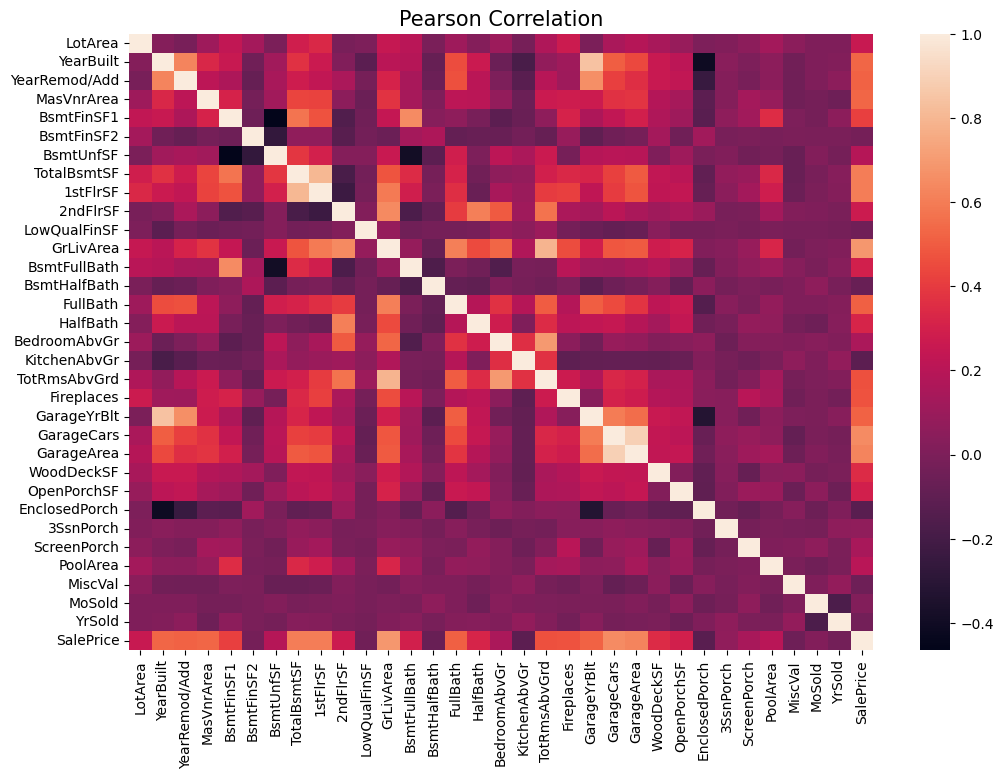

In [26]:
df_train_num = df_train.select_dtypes(include='number')
df_pears_corr_train = df_train_num.corr(method='pearson')
fig = plt.figure(figsize=(12, 8))
ax = sns.heatmap(df_pears_corr_train)
ax.set_title('Pearson Correlation', size=15)
fig.add_axes(ax)
plt.show()

Highly (positive) correlated numerical features: (*GarageCars*, *GarageArea*), (*GarageYrBuilt*, (*YearBuilt*, *YearRemod/Add*)), (*GrLivArea*,(*TotRmsAbvGrd*, *1stFlrSF*, *2ndFlrSF*, *FullBath*)).

Highly (negative) correlated numerical features: (*EnclosedPorch*, (*YearBuilt*, *YearRemodAdd*, *GarageYrBuilt*)), (*BsmtUnfSF*, (*BsmtFinSF1*, *BsmtFullBath*)),

Numerical features with high correlation with the target: *GrLivArea*, *GarageArea*, *GarageCars*

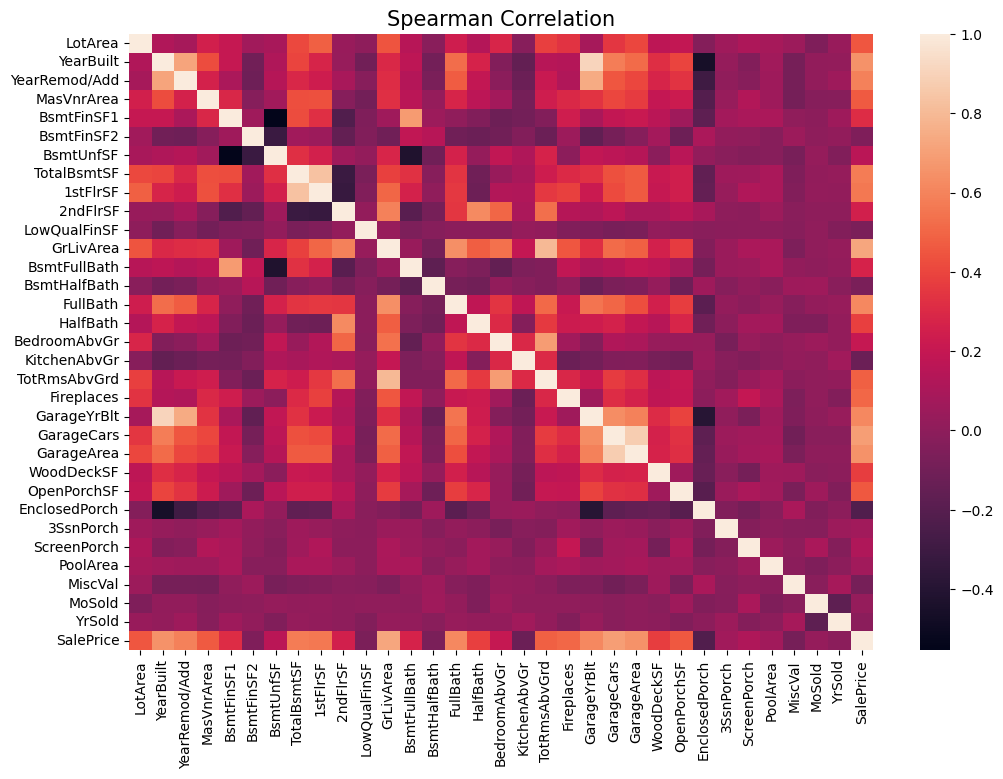

In [27]:
df_spearman_corr_train = df_train_num.corr(method='spearman')
fig = plt.figure(figsize=(12, 8))
ax = sns.heatmap(df_spearman_corr_train)
ax.set_title('Spearman Correlation', size=15)
fig.add_axes(ax)
plt.show()

In [28]:
# Impute NaN to calculate MI scores
X_train_num  = X_train.select_dtypes(include='number')

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_num_imp = imputer.fit_transform(X_train_num)
X_train_num_imp = pd.DataFrame(X_train_num_imp, columns=X_train_num.columns, index=X_train_num.index)
X_train_num_imp.isna().sum().sum()

np.int64(0)

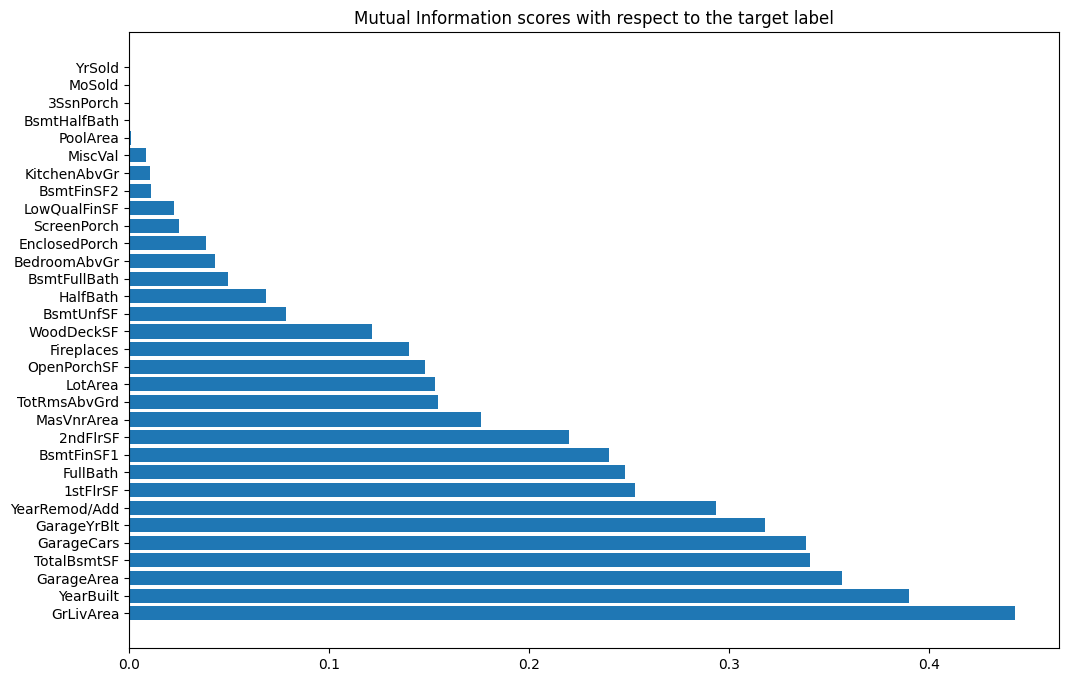

In [36]:
# Calculate and plot MI Scores
from sklearn.feature_selection import mutual_info_regression

discrete_feat = X_train_num_imp.dtypes == 'Int64'

def get_mi_scores(X, y, discrete_feat):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_feat)
    mi_scores = pd.Series(mi_scores, name='MI Scores' ,index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(mi_scores):
    plt.figure(figsize=(12,8))
    plt.barh(mi_scores.index, mi_scores.values)
    plt.title('Mutual Information scores with respect to the target label')
    plt.show()

mi_scores = get_mi_scores(X_train_num_imp, y_train, discrete_feat)
plot_mi_scores(mi_scores)

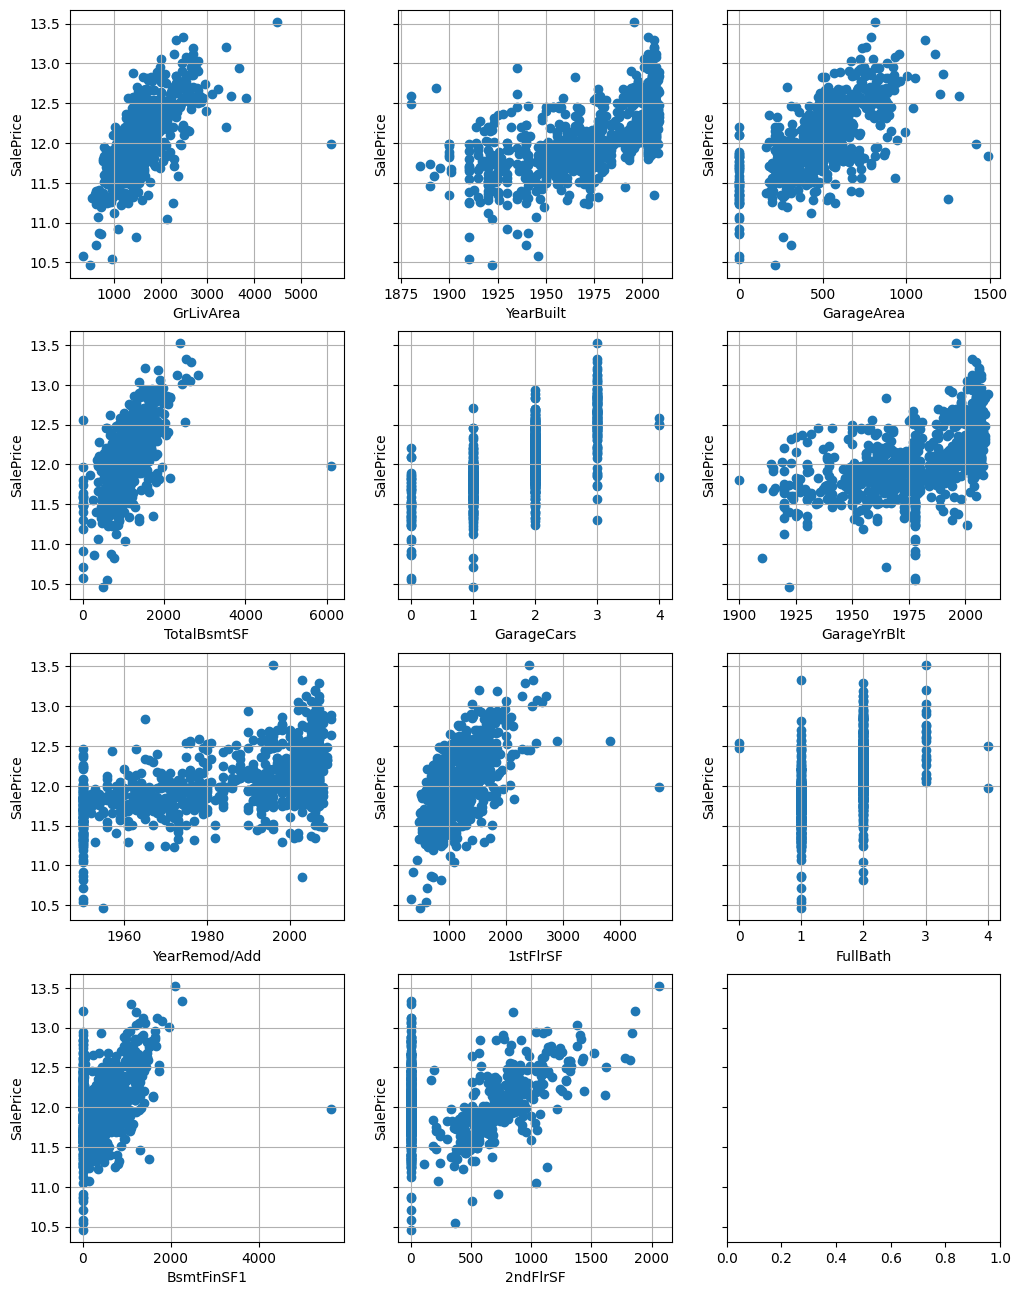

In [51]:
# Plot the features with relatively high MI score
mi_threshold = 0.2
high_mi_score_feat_cols = mi_scores[mi_scores > mi_threshold].index

fig, axes = plt.subplots(4, 3, sharey=True, figsize=(12,16))
for i, ax in enumerate(axes.flatten()):
    if i == len(high_mi_score_feat_cols):
        break
    col = high_mi_score_feat_cols[i]
    ax.scatter(X_train_num_imp[col], np.log(y_train.values))
    ax.set_xlabel(f'{col}')
    ax.set_ylabel('SalePrice')
    ax.grid()

plt.show()

# Categorical Features

In [ ]:
# Calculate ANOVA
from sklearn.feature_selection import f_classif

X_train_cat = X_train.select_dtypes(exclude='number')
X_train_cat_enc = X_train_cat.apply(lambda x : x.cat.codes)
f_stat, p_val = f_classif(X_train_cat_enc, y_train)
anova_arr = np.vstack((f_stat, p_val)).T
anova_df = pd.DataFrame(anova_arr, columns=['f-statistic', 'p-value'], index=X_train_cat_enc.columns)

,f-statistic,p-value
MSSubClass,0.929449,7.781982e-01
MSZoning,1.218152,2.037940e-02
Street,5.812629,9.723551e-65
LotShape,1.297985,3.457829e-03
LandContour,1.133987,9.600644e-02
Utilities,0.245108,1.000000e+00
LotConfig,0.854496,9.499794e-01
LandSlope,1.064734,2.577976e-01
Neighborhood,1.166866,5.469902e-02
Condition1,0.713090,9.997973e-01


In [ ]:
# Keep only statistically relevant features
relevant_cat_feat = anova_df[(anova_df['f-statistic'] > 2.) & (anova_df['p-value'] < 0.001)].index

Index(['Street', 'OverallQual', 'RoofMatl', 'ExterQual', 'BsmtQual',
       'KitchenQual'],
      dtype='str')

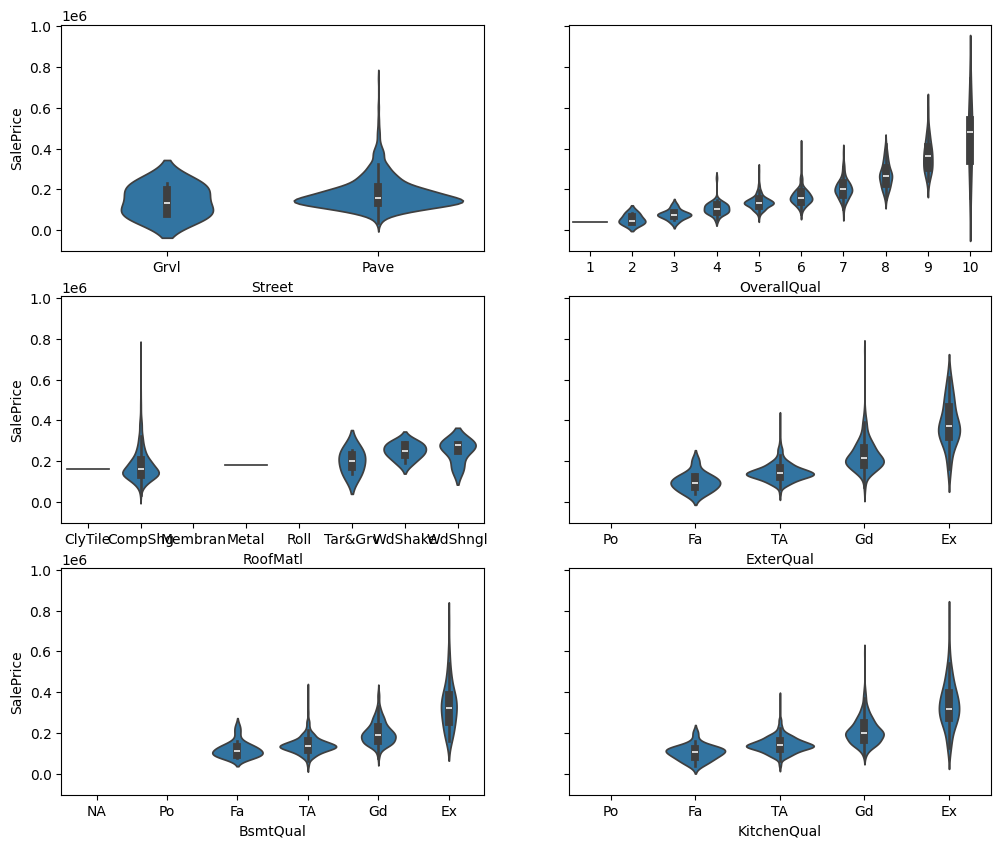

In [64]:
# Plot relevant categorical features against the target variable 
# with violin plots

fig, axes = plt.subplots(3, 2, figsize=(12,10), sharey=True)
for i, ax in enumerate(axes.flatten()):
    col = relevant_cat_feat[i]
    sns.violinplot(x=X_train_cat[col], y=y_train, ax=ax)
    ax.set_xlabel(f'{col}')
    ax.set_ylabel('SalePrice')

plt.show()